# 02 - Maximum Softmax Probability (MSP) Baseline for OOD Detection

**Out-of-distribution (OOD) detection** asks a trained classifier a question it
was never trained to answer directly: *"have you ever seen anything like this
input before?"* A network trained only on handwritten digits (MNIST) has no
notion of a shirt or a sneaker (FashionMNIST) -- but if we feed it one anyway,
it will still confidently output a 10-way softmax distribution over digit
classes, because softmax always sums to 1 no matter how alien the input is.

Hendrycks & Gimpel (2017), *"A Baseline for Detecting Misclassified and
Out-of-Distribution Examples in Neural Networks"* (arXiv:1610.02136), propose
the simplest possible detector: use the network's own **maximum softmax
probability (MSP)** as a confidence/OOD score. The intuition is that a
classifier tends to be less confident (lower max softmax probability) on
inputs unlike its training distribution, even with no special training for
OOD detection at all -- it is a *post-hoc* score computed from an ordinarily
trained classifier.

This notebook builds that baseline from scratch:

1. Train a tiny CNN on MNIST (in-distribution, "ID").
2. Score MNIST-test (ID) and FashionMNIST-test (OOD) with MSP.
3. Plot the ID vs OOD score histograms.
4. Compute the two standard OOD-detection metrics: **AUROC** and **FPR@95TPR**.

Later notebooks in this topic improve on MSP's weaknesses; this one just
establishes the baseline and the evaluation machinery.

## Setup and reproducibility

Imports, a fixed seed, `DEVICE = cpu`, and the repo's `data/` directory
resolved by walking up from the current working directory until we find
`pyproject.toml` (so the notebook runs correctly regardless of the working
directory Jupyter was launched from). Both MNIST and FashionMNIST are already
downloaded there, so we pass `download=False` and never touch the network.

In [1]:
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

torch.manual_seed(0)
np.random.seed(0)
DEVICE = torch.device("cpu")

# Resolve the repo data dir regardless of where the notebook runs from.
_r = Path.cwd()
while not (_r / "pyproject.toml").exists() and _r != _r.parent:
    _r = _r.parent
DATA_ROOT = str(_r / "data")
print("data root:", DATA_ROOT)


data root: c:\Users\abero\dev\applied_learning\data


## Data: MNIST is ID, FashionMNIST is OOD

Both datasets are 28x28 grayscale with 10 classes, so they are shape-compatible
with the exact same CNN and the exact same normalization -- which makes this a
clean, controlled OOD setup (the *only* thing that differs is the visual
content). We use small subsets so everything trains and scores in seconds:

- **MNIST train subset** (10000 images): trains the classifier.
- **MNIST test subset** (2000 images): the **in-distribution (ID)** eval set.
- **FashionMNIST test subset** (2000 images): the **out-of-distribution (OOD)**
  eval set -- the CNN never saw a single FashionMNIST image during training.

We normalize with MNIST's standard mean/std for both datasets. This is
deliberate: we want the OOD-ness to come from the image *content*, not from an
avoidable input-scaling mismatch.

In [2]:
TRAIN_N = 10000
TEST_N = 2000
BATCH = 128

transform = transforms.Compose([
    transforms.ToTensor(),                 # -> [0, 1], shape (1, 28, 28)
    transforms.Normalize((0.1307,), (0.3081,)),
])

mnist_train_full = datasets.MNIST(DATA_ROOT, train=True, download=False, transform=transform)
mnist_test_full = datasets.MNIST(DATA_ROOT, train=False, download=False, transform=transform)
fmnist_test_full = datasets.FashionMNIST(DATA_ROOT, train=False, download=False, transform=transform)

train_idx = torch.randperm(len(mnist_train_full))[:TRAIN_N].tolist()
mnist_test_idx = torch.randperm(len(mnist_test_full))[:TEST_N].tolist()
fmnist_test_idx = torch.randperm(len(fmnist_test_full))[:TEST_N].tolist()

train_ds = Subset(mnist_train_full, train_idx)
id_test_ds = Subset(mnist_test_full, mnist_test_idx)      # ID = MNIST test
ood_test_ds = Subset(fmnist_test_full, fmnist_test_idx)   # OOD = FashionMNIST test

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
id_test_loader = DataLoader(id_test_ds, batch_size=256, shuffle=False)
ood_test_loader = DataLoader(ood_test_ds, batch_size=256, shuffle=False)

print(f"train: {len(train_ds)} (MNIST)  id-test: {len(id_test_ds)} (MNIST)  ood-test: {len(ood_test_ds)} (FashionMNIST)")


train: 10000 (MNIST)  id-test: 2000 (MNIST)  ood-test: 2000 (FashionMNIST)


## A tiny CNN classifier

Two conv+pool blocks (28->14->7) followed by two fully-connected layers down
to 10 digit classes. Small enough to train a few epochs on a CPU subset in a
few seconds, but expressive enough to reach a solid MNIST test accuracy.

In [3]:
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(32 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # (B, 16, 14, 14)
        x = self.pool(F.relu(self.conv2(x)))   # (B, 32, 7, 7)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)                     # raw logits, shape (B, 10)


model = TinyCNN().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"TinyCNN parameters: {n_params}")


TinyCNN parameters: 105866


## Train on the MNIST subset

A few epochs of Adam over the 10000-image MNIST subset, cross-entropy loss on
raw logits. This is deliberately brief -- the point is a reasonably accurate
digit classifier, not a state-of-the-art one.

In [4]:
EPOCHS = 3

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

t0 = time.time()
model.train()
for epoch in range(EPOCHS):
    total_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    print(f"epoch {epoch + 1}/{EPOCHS}  avg train loss: {total_loss / len(train_ds):.4f}")
print(f"training time: {time.time() - t0:.1f}s")


epoch 1/3  avg train loss: 0.8022


epoch 2/3  avg train loss: 0.2474


epoch 3/3  avg train loss: 0.1591
training time: 11.7s


## Sanity check: MNIST test accuracy

Before trusting any OOD score derived from this classifier, we confirm it
actually learned to classify digits -- we expect well above 95% test accuracy
on in-distribution MNIST test images.

In [5]:
@torch.no_grad()
def accuracy(m, loader):
    m.eval()
    correct = 0
    total = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        pred = m(xb).argmax(dim=1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)
    return correct / total


test_acc = accuracy(model, id_test_loader)
print(f"MNIST (ID) test accuracy: {test_acc * 100:.2f}%")
assert test_acc > 0.95, "sanity check failed: MNIST test accuracy should exceed 95%"


MNIST (ID) test accuracy: 95.85%


## The MSP score

For every test image we run a forward pass, apply softmax to the logits, and
take the **maximum class probability**:

```
s(x) = max_c softmax(f(x))_c
```

`s(x)` is close to 1 when the network is confident in one class and lower
when the softmax distribution is flatter (spread across several classes).
Hendrycks & Gimpel's baseline hypothesis: `s(x)` tends to be **lower on OOD
inputs** than on ID inputs, purely as a side effect of ordinary training --
even though nothing about training ever mentioned "OOD".

In [6]:
@torch.no_grad()
def msp_scores(m, loader):
    m.eval()
    scores = []
    for xb, _ in loader:
        xb = xb.to(DEVICE)
        probs = F.softmax(m(xb), dim=1)
        scores.append(probs.max(dim=1).values.numpy())
    return np.concatenate(scores)


msp_id = msp_scores(model, id_test_loader)     # MNIST (ID)
msp_ood = msp_scores(model, ood_test_loader)   # FashionMNIST (OOD)

print(f"ID  MSP:  mean={msp_id.mean():.3f}  median={np.median(msp_id):.3f}")
print(f"OOD MSP:  mean={msp_ood.mean():.3f}  median={np.median(msp_ood):.3f}")


ID  MSP:  mean=0.941  median=0.991
OOD MSP:  mean=0.754  median=0.801


## Histogram: ID vs OOD confidence

If MSP is doing its job, the ID (MNIST) histogram should pile up near 1.0
(the network is confident and, per the accuracy check above, usually
correct), while the OOD (FashionMNIST) histogram should be lower and more
spread out -- the network is forced to pick some digit class for a shirt or
a shoe, and does so with less conviction on average.

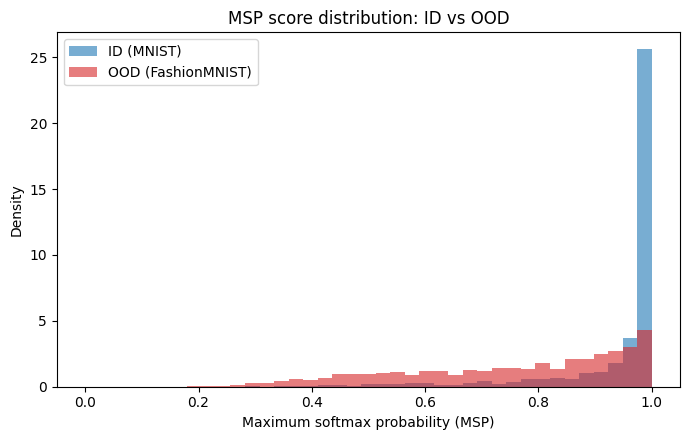

In [7]:
plt.figure(figsize=(7, 4.5))
bins = np.linspace(0, 1, 40)
plt.hist(msp_id, bins=bins, alpha=0.6, label="ID (MNIST)", color="tab:blue", density=True)
plt.hist(msp_ood, bins=bins, alpha=0.6, label="OOD (FashionMNIST)", color="tab:red", density=True)
plt.xlabel("Maximum softmax probability (MSP)")
plt.ylabel("Density")
plt.title("MSP score distribution: ID vs OOD")
plt.legend()
plt.tight_layout()
plt.show()


## Metric 1: AUROC

**Convention (stated explicitly, so the sign of the result is unambiguous):**
we treat **in-distribution (ID) as the positive class** (label `1`) and
**out-of-distribution (OOD) as the negative class** (label `0`), and we use
the **raw MSP value as the score** -- a higher MSP means the detector is
predicting "this is ID". Under this convention a *good* detector scores
**AUROC > 0.5** (and 1.0 is perfect separation): it means ID examples tend to
receive a higher MSP than OOD examples, exactly the behavior we plotted
above.

(An equally valid mirror convention treats OOD as positive and uses `-MSP` as
the OOD score; that would flip which class is "1" but yield the identical
AUROC value, since AUROC only depends on the induced ranking between the two
groups.)

In [8]:
y_true = np.concatenate([np.ones_like(msp_id), np.zeros_like(msp_ood)])   # 1 = ID, 0 = OOD
scores = np.concatenate([msp_id, msp_ood])                                 # higher = "more ID-like"

auroc = roc_auc_score(y_true, scores)
print(f"AUROC (ID=positive, score=MSP): {auroc:.4f}")


AUROC (ID=positive, score=MSP): 0.8486


## Metric 2: FPR@95TPR

**FPR@95TPR** answers a more operational question than AUROC: *"if we set the
detector's threshold to correctly keep 95% of in-distribution inputs, what
fraction of OOD inputs slip through and also get accepted as ID?"*

Using the same ID-as-positive / MSP-as-score convention as above:

1. Find the threshold `tau` such that 95% of ID scores are `>= tau` (i.e.
   `tau` is the 5th percentile of the ID MSP scores) -- this is the "TPR = 95%
   on ID" operating point.
2. **FPR** is the fraction of OOD scores that are *also* `>= tau` -- i.e. OOD
   inputs the detector mistakes for ID at that threshold.

Lower FPR@95TPR is better (0 = perfect separation at that operating point).

In [9]:
def fpr_at_95_tpr(id_scores: np.ndarray, ood_scores: np.ndarray, tpr_target: float = 0.95):
    # Threshold such that tpr_target fraction of ID scores sit at or above it.
    tau = np.percentile(id_scores, 100.0 * (1.0 - tpr_target))
    tpr = np.mean(id_scores >= tau)     # should land close to tpr_target
    fpr = np.mean(ood_scores >= tau)    # OOD inputs wrongly accepted as ID
    return fpr, tau, tpr


fpr95, tau, achieved_tpr = fpr_at_95_tpr(msp_id, msp_ood)
print(f"threshold tau: {tau:.4f}  (achieved ID TPR: {achieved_tpr * 100:.1f}%)")
print(f"FPR@95TPR: {fpr95 * 100:.2f}%")


threshold tau: 0.6720  (achieved ID TPR: 95.0%)
FPR@95TPR: 67.80%


## Takeaways

MSP gets the core idea right and for free: a classifier trained purely for
in-distribution accuracy already carries *some* separation signal for
OOD detection in its own softmax output, with zero extra training and one
line of code (`max(softmax(logits))`). That is exactly why Hendrycks & Gimpel
(2017) frame it as a *baseline* every fancier method must beat.

Its well-known weakness is **overconfidence**: modern networks (especially
with ReLUs and unbounded logit magnitudes) can be pushed to produce a
near-1.0 max softmax probability on inputs that look nothing like training
data, simply because softmax normalizes whatever logits it receives -- there
is no mechanism forcing "unfamiliar input" to map to "flat distribution."
The histogram above usually still shows OOD leaking into the high-confidence
region for exactly this reason. Later notebooks in this topic address this
gap with scores that look beyond the softmax layer (e.g. energy-based or
feature-distance scores).